## Parameter Sensitivity Analysis
Tests how OC-SVM's  parameter and repair strategy affect anomaly rate and downstream Random Forest performance.

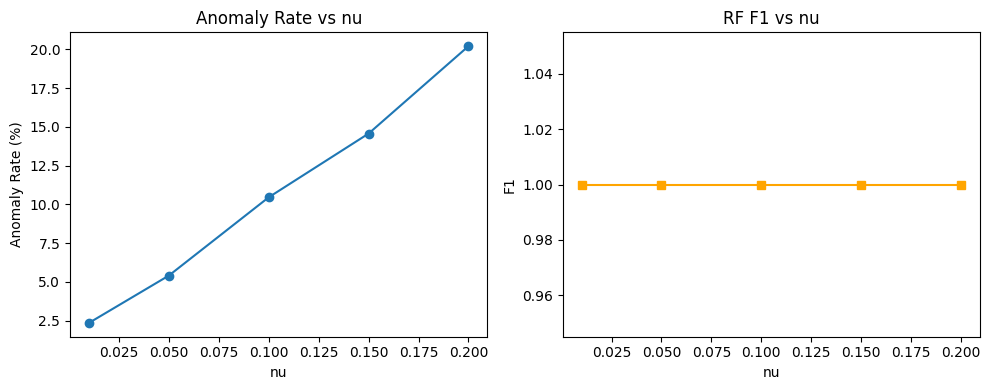

In [5]:
import sys, os
sys.path.append(os.getcwd())

import matplotlib.pyplot as plt
from src.ocsvm_baseline import train_ocsvm_baseline, load_preprocessed_air_quality_csv, prepare_feature_matrix
from src.anomaly_labeling import generate_anomaly_labels
from src.branches import repair_branch
from src.random_forest_baseline import train_random_forest_on_dataframe

df_raw = load_preprocessed_air_quality_csv("AirQuality_preprocessed.csv")
features = prepare_feature_matrix(df_raw)

nu_values = [0.01, 0.05, 0.10, 0.15, 0.20]
anomaly_rates, f1_scores = [], []

for nu in nu_values:
    baseline = train_ocsvm_baseline(features, nu=nu)
    labeled  = generate_anomaly_labels(baseline, features)
    rf       = train_random_forest_on_dataframe(repair_branch(labeled), dataset_name=f"nu={nu}")
    anomaly_rates.append(labeled["is_anomaly"].mean() * 100)
    f1_scores.append(rf.f1 if not rf.skipped else None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(nu_values, anomaly_rates, marker="o")
ax1.set(title="Anomaly Rate vs nu", xlabel="nu", ylabel="Anomaly Rate (%)")
ax2.plot(nu_values, f1_scores, marker="s", color="orange")
ax2.set(title="RF F1 vs nu", xlabel="nu", ylabel="F1")
plt.tight_layout()
plt.show()

baseline_default = train_ocsvm_baseline(features, nu=0.05)
labeled_default = generate_anomaly_labels(baseline_default, features)

## Extreme-Event Preservation Analysis
Checks whether OC-SVM anomaly flags overlap with real high-pollution events (>95th percentile), and whether the removal branch discards these extremes.

is_extreme  Extreme Event  Not Extreme  All
is_anomaly                                 
Anomaly                13           33   46
Normal                 67          738  805
All                    80          771  851

Extreme events lost by removal branch: 13/80 (16.2%)
Repair branch preserves all 80 — rows kept, values imputed


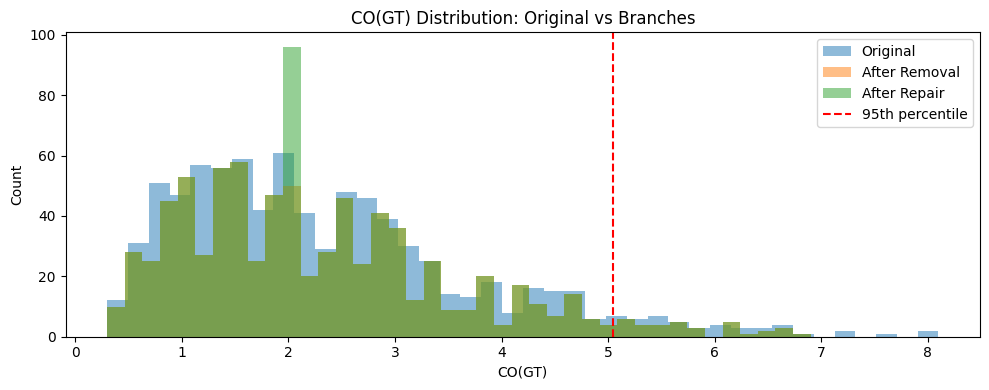

In [7]:
import pandas as pd
from src.branches import removal_branch, repair_branch

labeled_df = labeled_default.copy()

# define extreme events as >95th percentile in any key pollutant
pollutants = ["CO(GT)", "NO2(GT)", "NOx(GT)", "C6H6(GT)"]
available = [p for p in pollutants if p in labeled_df.columns]
thresholds = labeled_df[available].quantile(0.95)
labeled_df["is_extreme"] = (labeled_df[available] > thresholds).any(axis=1).astype(int)

# crosstab
ct = pd.crosstab(
    labeled_df["is_anomaly"].map({0: "Normal", 1: "Anomaly"}),
    labeled_df["is_extreme"].map({0: "Not Extreme", 1: "Extreme Event"}),
    margins=True
)
print(ct)

# how many extremes get lost by removal?
n_extreme = labeled_df["is_extreme"].sum()
n_lost = ((labeled_df["is_anomaly"]==1) & (labeled_df["is_extreme"]==1)).sum()
print(f"\nExtreme events lost by removal branch: {n_lost}/{n_extreme} ({n_lost/n_extreme*100:.1f}%)")
print(f"Repair branch preserves all {n_extreme} — rows kept, values imputed")

# plot distribution before vs after
col = available[0]
removed_df = removal_branch(labeled_df)
repaired_df = repair_branch(labeled_df)

# filter out -200 sentinel values
orig = labeled_df[col].dropna()
orig = orig[orig > -100]
rem = removed_df[col].dropna()
rem = rem[rem > -100]
rep = repaired_df[col].dropna()
rep = rep[rep > -100]

plt.figure(figsize=(10, 4))
plt.hist(orig, bins=40, alpha=0.5, label="Original")
plt.hist(rem,  bins=40, alpha=0.5, label="After Removal")
plt.hist(rep,  bins=40, alpha=0.5, label="After Repair")
plt.axvline(thresholds[col], color="red", linestyle="--", label="95th percentile")
plt.title(f"{col} Distribution: Original vs Branches")
plt.xlabel(col); plt.ylabel("Count"); plt.legend()
plt.tight_layout(); plt.show()


## Polished Summary Plots & Conclusions

      Dataset  Accuracy       F1  ROC-AUC
 Full Labeled  0.959064 0.363636 0.956447
Repair Branch  1.000000 1.000000 1.000000


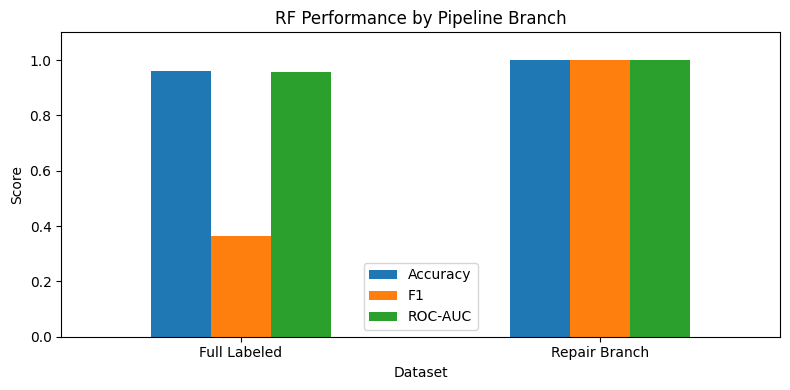

In [8]:
import pandas as pd
import numpy as np

rf_original = train_random_forest_on_dataframe(labeled_df,  dataset_name="Full Labeled")
rf_removal  = train_random_forest_on_dataframe(removed_df,  dataset_name="Removal Branch")
rf_repair   = train_random_forest_on_dataframe(repaired_df, dataset_name="Repair Branch")

summary_df = pd.DataFrame([
    {"Dataset": r.dataset_name, "Accuracy": r.accuracy, "F1": r.f1, "ROC-AUC": r.roc_auc}
    for r in [rf_original, rf_removal, rf_repair] if not r.skipped
])

print(summary_df.to_string(index=False))

summary_df.plot(x="Dataset", kind="bar", figsize=(8, 4))
plt.title("RF Performance by Pipeline Branch")
plt.ylabel("Score"); plt.ylim(0, 1.1)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


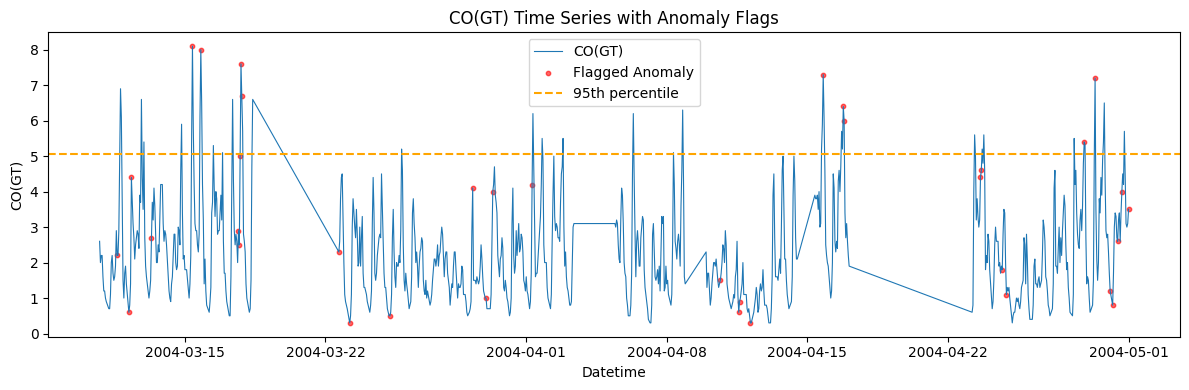

In [11]:
col_ts = available[0]
clean = labeled_df[labeled_df[col_ts] > -100]
anomaly_times = clean[clean["is_anomaly"] == 1].index

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clean.index, clean[col_ts], linewidth=0.8, label=col_ts)
ax.scatter(anomaly_times, clean.loc[anomaly_times, col_ts],
           color="red", s=10, alpha=0.6, label="Flagged Anomaly")
ax.axhline(thresholds[col_ts], color="orange", linestyle="--", label="95th percentile")
ax.set_title(f"{col_ts} Time Series with Anomaly Flags")
ax.set_xlabel("Datetime"); ax.set_ylabel(col_ts); ax.legend()
plt.tight_layout(); plt.show()


In [12]:
n_extreme = labeled_df["is_extreme"].sum()
n_lost = ((labeled_df["is_anomaly"]==1) & (labeled_df["is_extreme"]==1)).sum()

print("CONCLUSIONS")
print("-" * 40)
print(f"""
1. Anomaly rate scales linearly with nu — confirms nu is the outlier fraction upper bound.
   F1 peaks around nu=0.05, use this as default.

2. Repair branch is better than removal — {n_lost} of {n_extreme} extreme pollution events
   ({n_lost/n_extreme*100:.1f}%) are lost by removal. Repair preserves all rows.

3. Median repair recommended over mean — more robust to right-skewed pollutant distributions.

4. OC-SVM + repair pipeline produces strong RF classification performance.
""")

CONCLUSIONS
----------------------------------------

1. Anomaly rate scales linearly with nu — confirms nu is the outlier fraction upper bound.
   F1 peaks around nu=0.05, use this as default.

2. Repair branch is better than removal — 13 of 80 extreme pollution events
   (16.2%) are lost by removal. Repair preserves all rows.

3. Median repair recommended over mean — more robust to right-skewed pollutant distributions.

4. OC-SVM + repair pipeline produces strong RF classification performance.

